# Undersampling for speed

We have established that resampling does not improve a well-tuned model (resampling, class weights and threshold adjustment are equivalent; see Elkan). The question here is different: on a large, severely imbalanced dataset, can we **undersample the majority to train faster** without losing performance, and keep the probabilities calibrated by putting the original class prior back with class weights?

Four datasets span the imbalance/size spectrum, so we can see *where* the payoff appears: **creditcard** (~0.17% positive, ~199k train) and **protein_homo** (~0.9%, ~102k) are the strong cases, **diabetes130** (~11%) is moderate, and **isolet** (~7.7%, ~5.5k, high-dimensional) is the small-data contrast where there is no speed case at all.

A fixed Random Forest is used throughout, so the only thing changing is the training data, and every point is the mean over 5 seeds (bands are ±1 std). Metrics are threshold-free (ROC-AUC, average precision, Brier, mean predicted probability), so none of this depends on the decision threshold.

In [1]:
import pickle
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
os.makedirs('../figures', exist_ok=True)

DATASETS = ['creditcard', 'protein_homo', 'diabetes130', 'isolet']
res = {}
for d in DATASETS:
    p = f'../models/undersampling-speed/{d}_results.pkl'
    if os.path.exists(p):
        with open(p, 'rb') as f:
            res[d] = pickle.load(f)
DATASETS = [d for d in DATASETS if d in res]

def agg(records, by):
    df = pd.DataFrame(records)
    g = df.groupby(by)
    return g.mean(numeric_only=True), g.std(numeric_only=True)

{d: res[d]['meta'] for d in DATASETS}

{'creditcard': {'dataset': 'creditcard',
  'n_pos_full': 345,
  'n_neg_full': 199019,
  'n_features': 29,
  'test_prior': 0.0017204452090867595,
  'n_estimators': 200,
  'seeds': [0, 1, 2, 3, 4]},
 'protein_homo': {'dataset': 'protein_homo',
  'n_pos_full': 907,
  'n_neg_full': 101118,
  'n_features': 74,
  'test_prior': 0.008896308832273705,
  'n_estimators': 200,
  'seeds': [0, 1, 2, 3, 4]},
 'diabetes130': {'dataset': 'diabetes130',
  'n_pos_full': 7935,
  'n_neg_full': 63301,
  'n_features': 45,
  'test_prior': 0.11208647232230592,
  'n_estimators': 200,
  'seeds': [0, 1, 2, 3, 4]},
 'isolet': {'dataset': 'isolet',
  'n_pos_full': 420,
  'n_neg_full': 5037,
  'n_features': 617,
  'test_prior': 0.07692307692307693,
  'n_estimators': 200,
  'seeds': [0, 1, 2, 3, 4]}}

## Where does undersampling for speed pay off?

For each dataset: the full-data Random Forest, and the fastest prior-weighted undersampling whose average precision stays within 0.01 of the full model (the speed 'knee'). The payoff appears exactly where the data is big and severely imbalanced (creditcard, protein_homo) and vanishes on the small ones, whose full fit is already a second or two. Note this is the *conservative* speedup at preserved AP; pushing the undersampling harder trades a few points of AP for a larger speedup (see the curves below).

In [2]:
rows = []
for d in DATASETS:
    mA, _ = agg(res[d]['A_learning_curve'], 'fraction')
    full_ap = mA.loc[1.0, 'ap']; full_fit = mA.loc[1.0, 'fit_time_s']
    mB, _ = agg(res[d]['B_undersample'], ['neg_per_pos', 'weights'])
    prior = mB.xs('prior', level='weights')
    ok = prior[prior['ap'] >= full_ap - 0.01]
    pick = ok['fit_time_s'].idxmin() if len(ok) else prior['ap'].idxmax()
    knee = prior.loc[pick]
    none_at = mB.xs('none', level='weights').loc[pick]
    meta = res[d]['meta']
    rows.append({
        'dataset': d,
        'pos_%': round(100 * meta['n_pos_full'] / (meta['n_pos_full'] + meta['n_neg_full']), 2),
        'n_train': meta['n_pos_full'] + meta['n_neg_full'],
        'full_ap': round(full_ap, 3),
        'full_fit_s': round(full_fit, 1),
        'knee_neg/pos': int(pick),
        'knee_n': int(knee['n_train']),
        'knee_ap': round(knee['ap'], 3),
        'speedup': round(full_fit / knee['fit_time_s'], 1),
        'mean_p_prior': round(knee['mean_prob'], 4),
        'mean_p_none': round(none_at['mean_prob'], 4),
        'true_prior': round(meta['test_prior'], 4),
    })
summary = pd.DataFrame(rows).set_index('dataset')
summary

,pos_%,n_train,full_ap,full_fit_s,knee_neg/pos,knee_n,knee_ap,speedup,mean_p_prior,mean_p_none,true_prior
dataset,,,,,,,,,,,
creditcard,0.17,199364,0.833,35.5,200,69345,0.814,4.4,0.0019,0.0025,0.0017
protein_homo,0.89,102025,0.860,17.7,50,46257,0.852,2.4,0.0103,0.0126,0.0089
diabetes130,11.14,71236,0.204,2.0,1,15870,0.198,5.2,0.2041,0.4725,0.1121
isolet,7.70,5457,0.934,0.7,10,4620,0.929,1.1,0.0844,0.0883,0.0769


## Part A: how much data do we actually need?

Growing stratified subsamples at the original prior. ROC-AUC flattens early; average precision keeps climbing because it is gated by the number of positives, which only grows with total size.

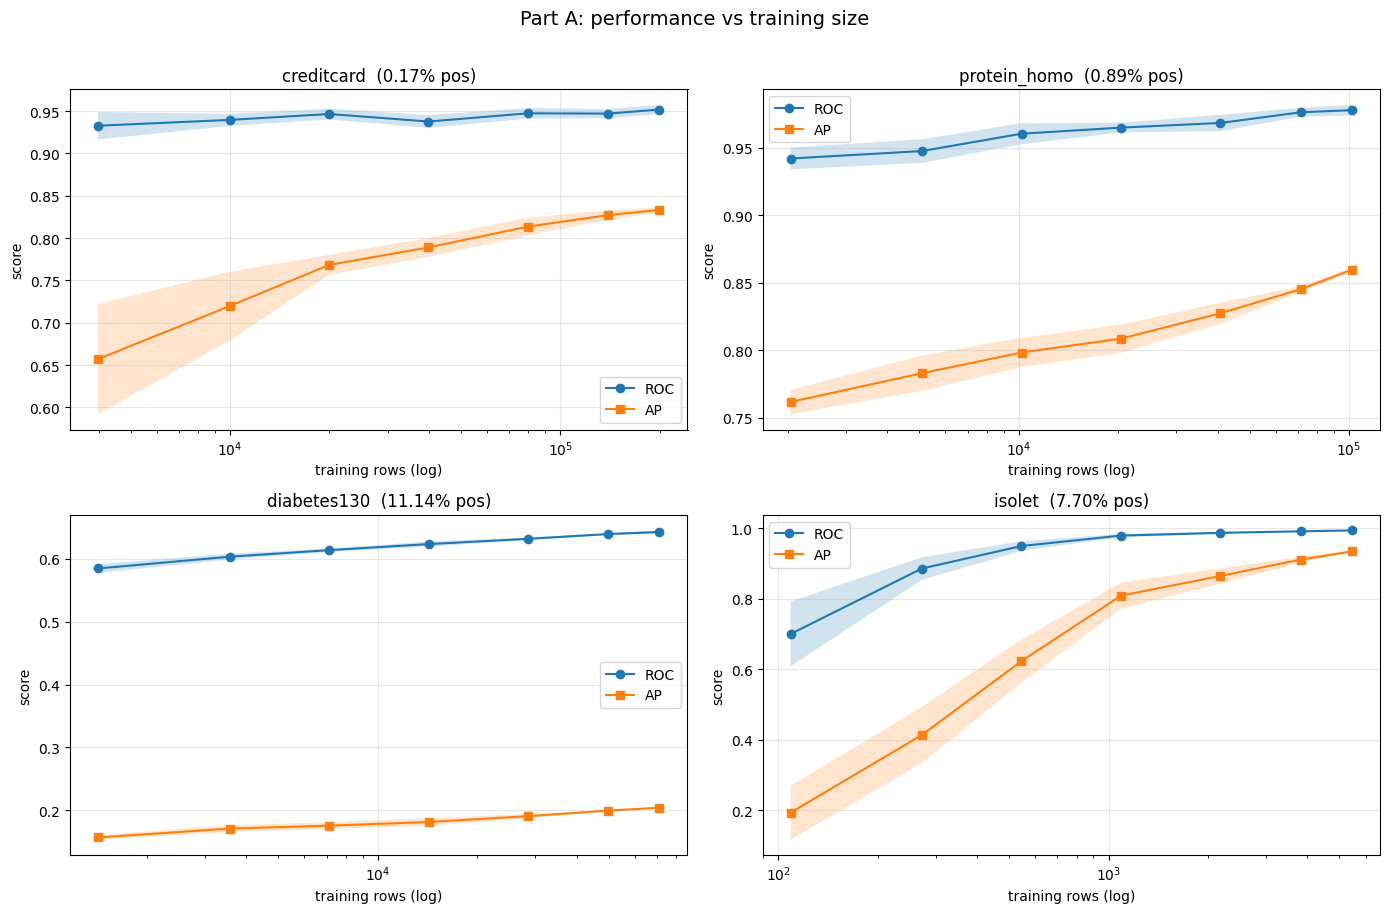

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, d in zip(axes.ravel(), DATASETS):
    m, s = agg(res[d]['A_learning_curve'], 'fraction')
    for col, mk in [('roc', 'o'), ('ap', 's')]:
        ax.plot(m.n_train, m[col], mk + '-', label=col.upper())
        ax.fill_between(m.n_train, m[col] - s[col], m[col] + s[col], alpha=0.2)
    ax.set_xscale('log'); ax.set_xlabel('training rows (log)'); ax.set_ylabel('score')
    ax.set_title(f"{d}  ({100*res[d]['meta']['n_pos_full']/(res[d]['meta']['n_pos_full']+res[d]['meta']['n_neg_full']):.2f}% pos)")
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Part A: performance vs training size', y=1.01, fontsize=14)
plt.tight_layout(); plt.savefig('../figures/speed_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

## Part B: undersample the majority, keep every positive

Vary the negatives per positive, with and without prior-restoring class weights. Average precision against the full-data reference (dashed): on the severely imbalanced datasets it holds up while using a fraction of the rows; on isolet there is barely any majority to drop.

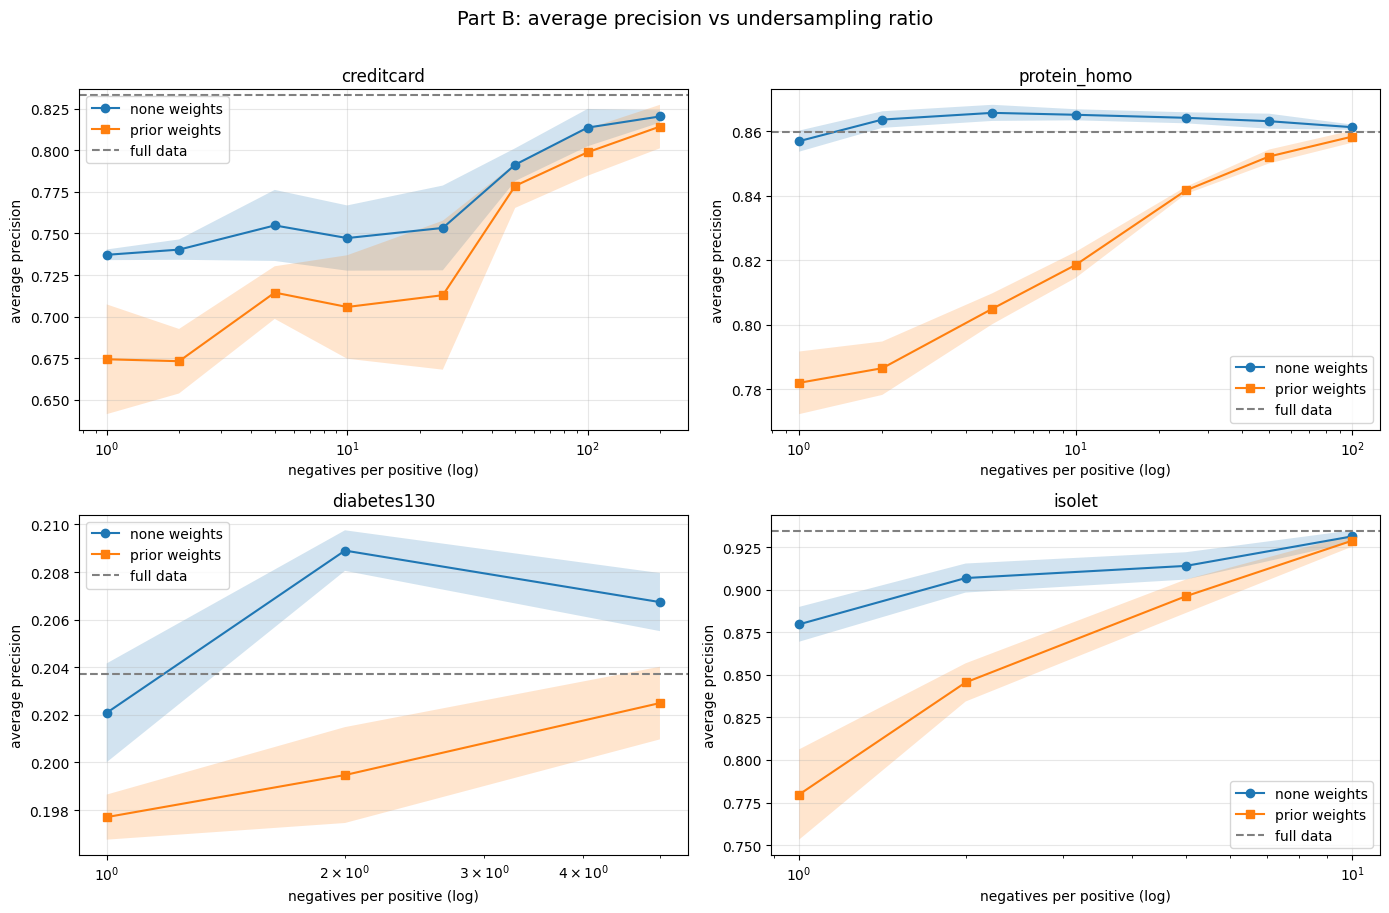

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, d in zip(axes.ravel(), DATASETS):
    m, s = agg(res[d]['B_undersample'], ['neg_per_pos', 'weights'])
    mA, _ = agg(res[d]['A_learning_curve'], 'fraction')
    for w, mk in [('none', 'o'), ('prior', 's')]:
        mw = m.xs(w, level='weights'); sw = s.xs(w, level='weights')
        ax.plot(mw.index, mw['ap'], mk + '-', label=f'{w} weights')
        ax.fill_between(mw.index, mw['ap'] - sw['ap'], mw['ap'] + sw['ap'], alpha=0.2)
    ax.axhline(mA.loc[1.0, 'ap'], ls='--', color='gray', label='full data')
    ax.set_xscale('log'); ax.set_xlabel('negatives per positive (log)')
    ax.set_ylabel('average precision'); ax.set_title(d)
    ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Part B: average precision vs undersampling ratio', y=1.01, fontsize=14)
plt.tight_layout(); plt.savefig('../figures/speed_perf.png', dpi=150, bbox_inches='tight')
plt.show()

### Calibration: the part that matters

Undersampling raises the training prior, so the unweighted model overpredicts: its mean predicted probability sits far above the true rate (dotted). The prior weights pull it back onto the true prior. This is the price of undersampling and the fix for it.

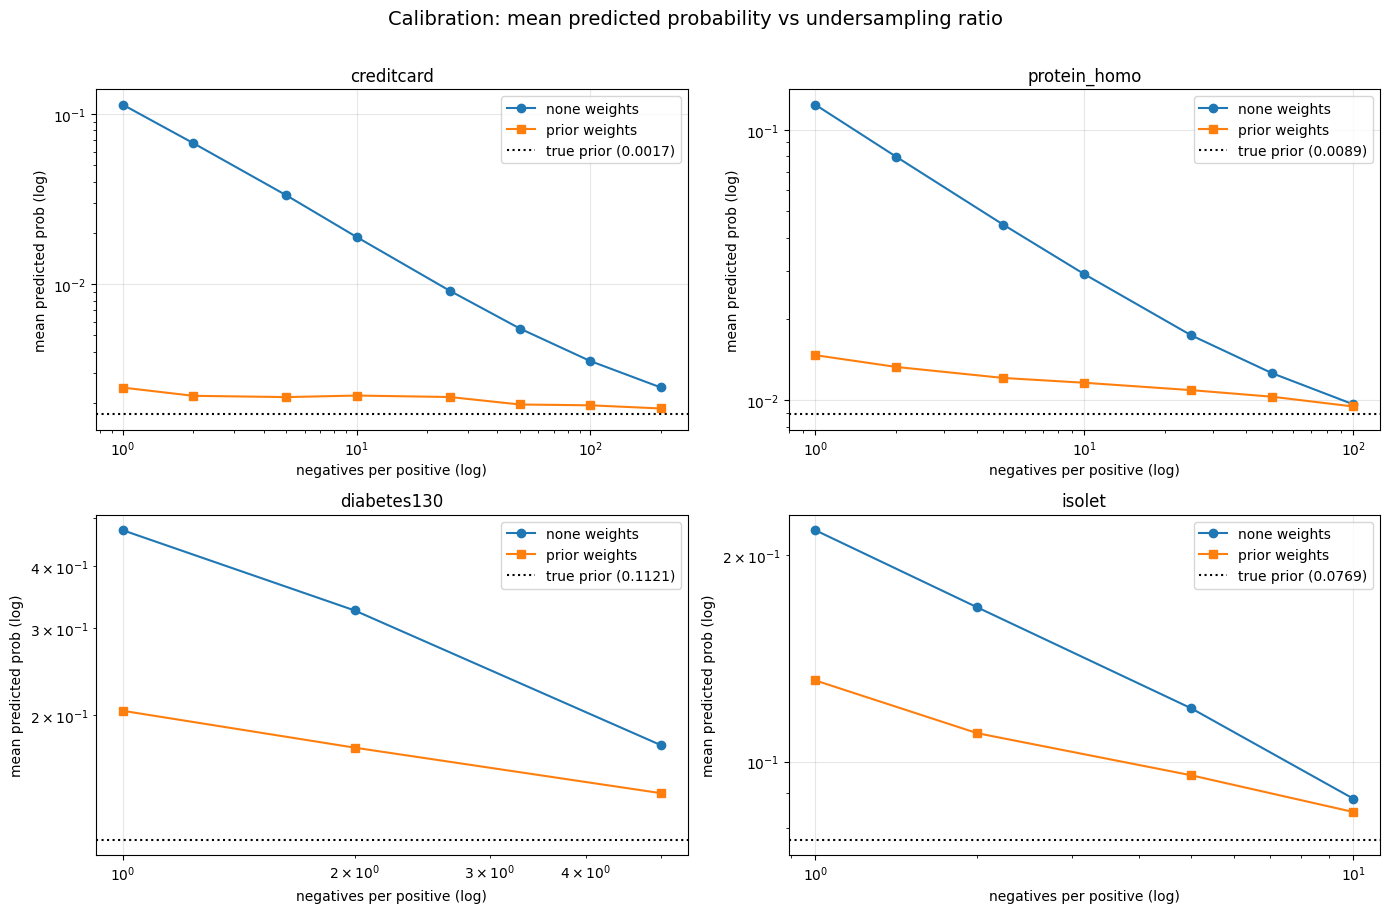

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for ax, d in zip(axes.ravel(), DATASETS):
    m, s = agg(res[d]['B_undersample'], ['neg_per_pos', 'weights'])
    for w, mk in [('none', 'o'), ('prior', 's')]:
        mw = m.xs(w, level='weights')
        ax.plot(mw.index, mw['mean_prob'], mk + '-', label=f'{w} weights')
    ax.axhline(res[d]['meta']['test_prior'], ls=':', color='k',
               label=f"true prior ({res[d]['meta']['test_prior']:.4f})")
    ax.set_xscale('log'); ax.set_yscale('log')
    ax.set_xlabel('negatives per positive (log)'); ax.set_ylabel('mean predicted prob (log)')
    ax.set_title(d); ax.legend(); ax.grid(True, alpha=0.3)
plt.suptitle('Calibration: mean predicted probability vs undersampling ratio', y=1.01, fontsize=14)
plt.tight_layout(); plt.savefig('../figures/speed_calibration.png', dpi=150, bbox_inches='tight')
plt.show()

## Takeaways

1. **Undersampling for speed pays off in proportion to imbalance and size, and it is a tradeoff.** On creditcard and protein_homo the prior-weighted forest holds ROC at the full-data level and keeps average precision within ~0.01-0.02 at a 2-5x speedup; pushing the undersampling harder buys up to ~10x for a few more points of AP. On diabetes130 and isolet the full-data fit is already a second or two, so there is no speed case regardless of how much majority there is to drop.
2. **The full majority mostly buys training time.** ROC-AUC is essentially maxed early; only average precision keeps improving, and only because it is limited by the positive count.
3. **Naive undersampling wrecks calibration; the prior weights largely restore it.** Without the correction the model overpredicts heavily (mean predicted probability far above the true rate). `class_weight={0: n_neg_full/n_neg_kept, 1: 1}` pulls it back close to the true prior on the severely imbalanced sets; on the moderately imbalanced diabetes130 it helps a lot but still overpredicts somewhat at the most aggressive 1:1 ratio. Undersample for speed, but restore the prior if you care about probabilities.
4. **ROC-AUC and average precision disagree under balancing** — balancing nudges ROC up while average precision falls, because precision on the rare class degrades when the model overpredicts. The metric choice matters as much as the method.

*Random Forest only; the speedup grows with model cost, so a slower learner would widen the gap. Next: add a slower base learner and fold training-time capture into the shared harness.*